<a href="https://colab.research.google.com/github/giharajayasinghe/Project1/blob/main/Using_ReLU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import os
from matplotlib import pyplot as plt
import numpy as np


if not os.path.exists('MNIST_dataset'):
  os.system('git clone https://github.com/DeepTrackAI/MNIST_dataset')

train_images = os.path.join('MNIST_dataset','mnist','train')
train_data_images = sorted(os.listdir(train_images))

In [64]:
train_data = []
for file in train_data_images:
  image = plt.imread(os.path.join(train_images,file))
  train_data.append(image)

In [65]:
digit_data = []
for digit in train_data_images:
  dig = os.path.basename(digit)
  digit_data.append(int(dig[0]))

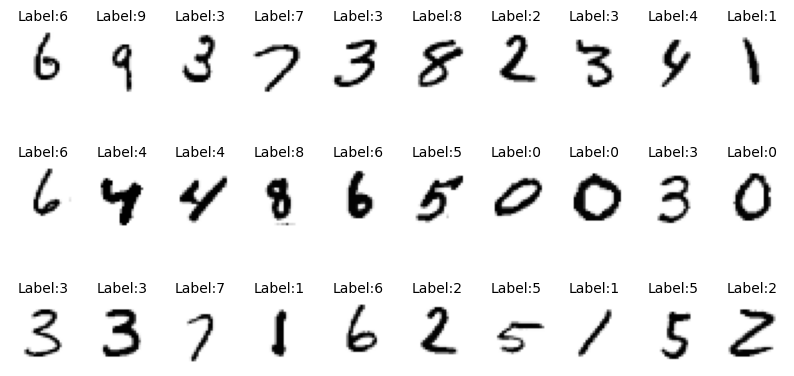

In [66]:
fig,alx = plt.subplots(figsize=(10,5),nrows=3,ncols=10)
for ax in alx.ravel():
  idx_img = np.random.choice(60000)
  ax.imshow(train_data[idx_img],cmap='Greys')
  ax.set_title(f"Label:{digit_data[idx_img]}",fontsize=10)
  ax.axis('off')
plt.show()

In [67]:
#Implementing the neural network
import deeplay as dl
from torch.nn import Softmax,MSELoss,ReLU

In [68]:
mlp_template = dl.MultiLayerPerceptron(
    in_features= 28*28,
    hidden_features=[32,32],
    out_features=10
)
mlp_template[...,'activation#:-1'].configure(ReLU)
mlp_model = mlp_template.create()

In [69]:
print(mlp_model)

MultiLayerPerceptron(
  (blocks): LayerList(
    (0): LinearBlock(
      (layer): Linear(in_features=784, out_features=32, bias=True)
      (activation): ReLU()
    )
    (1): LinearBlock(
      (layer): Linear(in_features=32, out_features=32, bias=True)
      (activation): ReLU()
    )
    (2): LinearBlock(
      (layer): Linear(in_features=32, out_features=10, bias=True)
      (activation): Identity()
    )
  )
)


In [70]:
from deeplay.applications.classification import classifier
classifier_template = dl.Classifier(
    model=mlp_model,
    num_classes=10,
    make_targets_one_hot=True,
    loss=MSELoss(),
    optimizer=dl.RMSprop(lr=0.001)
)
classifier = classifier_template.create()

In [71]:
print(classifier)

Classifier(
  (loss): MSELoss()
  (optimizer): RMSprop[RMSprop](lr=0.001)
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): MultiLayerPerceptron(
    (blocks): LayerList(
      (0): LinearBlock(
        (layer): Linear(in_features=784, out_features=32, bias=True)
        (activation): ReLU()
      )
      (1): LinearBlock(
        (layer): Linear(in_features=32, out_features=32, bias=True)
        (activation): ReLU()
      )
      (2): LinearBlock(
        (layer): Linear(in_features=32, out_features=10, bias=True)
        (activation): Identity()
      )
    )
  )
)


In [72]:
train_images_digits = list(zip(train_data,digit_data))
train_dataloader = dl.DataLoader(train_images_digits,shuffle=True)

In [73]:
trainer = dl.Trainer(max_epochs=1,accelerator='gpu')

In [74]:
trainer.fit(classifier,train_dataloader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MSELoss              │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │     0 │
│ 4 │ model         │ MultiLayerPerceptron │ 26.5 K │ train │     0 │
│ 5 │ optimizer     │ RMSprop              │      0 │ train │     0 │
└───┴───────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 26.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

In [75]:
#preparing to cal accuracy
test_path = os.path.join('MNIST_dataset','mnist','test')
test_image_files = sorted(os.listdir(test_path))

In [76]:
test_data,test_digit = [],[]
for im in test_image_files:
  image = plt.imread(os.path.join(test_path,im))
  test_data.append(image)

  digit = os.path.basename(os.path.join(test_path,im))
  test_digit.append(int(digit[0]))


In [77]:
test_image_digit = list(zip(test_data,test_digit))
test_image_digit_loader = dl.DataLoader(test_image_digit,
                                        shuffle=True)

In [78]:
#testing accuracy
trainer.test(classifier,test_image_digit_loader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Test metric          ┃         DataLoader 0         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ testMulticlassAccuracy_epoch │      0.9296000003814697      │
│       test_loss_epoch        │     0.012160500511527061     │
└──────────────────────────────┴──────────────────────────────┘

[{'test_loss_epoch': 0.012160500511527061,
  'testMulticlassAccuracy_epoch': 0.9296000003814697}]

In [79]:
#plotting the confusion matrix
import seaborn as sns
def confusion_matrix(classifier,dataloader):
  confusion_matrix = np.zeros((10,10),dtype=int)
  for image,git_digit in dataloader:
    predictions = classifier(image)
    max_prediction,pred_digit = predictions.max(dim=1)
    np.add.at(confusion_matrix,(git_digit,pred_digit),1)

  plt.figure(figsize=(10,8))
  sns.heatmap(confusion_matrix,annot=True,cmap="Blues",vmax=150,square=True,
              fmt='.0f')
  plt.xlabel('Predicted Digit')
  plt.ylabel('Ground Truth')
  plt.show()



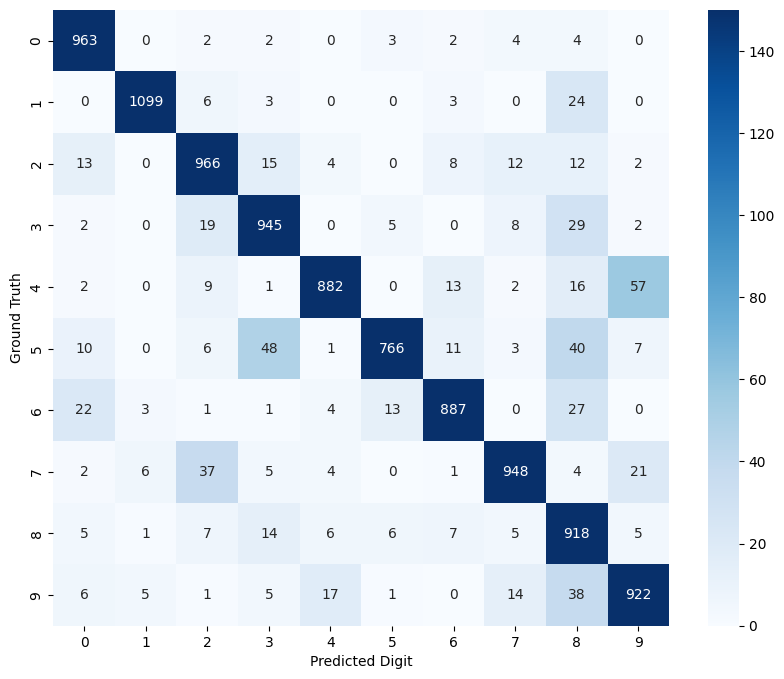

In [80]:
confusion_matrix(classifier,test_image_digit_loader)